In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# B[y_t, x_t, y_t+1, x_t+1] = p(s_t+1|s_t)
B = np.zeros((4, 4, 4, 4))

B[0, 0, 0, 1] = 1

B[1, 0, 0, 0] = 0.5
B[1, 0, 1, 1] = 0.5

B[2, 0, 1, 0] = 0.5
B[2, 0, 2, 1] = 0.5

B[3, 0, 2, 0] = 0.5
B[3, 0, 3, 1] = 0.5

B[0, 1, 0, 2] = 1

B[1, 1, 0, 1] = 0.5
B[1, 1, 1, 2] = 0.5

B[2, 1, 1, 1] = 0.5
B[2, 1, 2, 2] = 0.5

B[3, 1, 2, 1] = 0.5
B[3, 1, 3, 2] = 0.5

B[0, 2, 0, 3] = 1

B[1, 2, 0, 2] = 0.5
B[1, 2, 1, 3] = 0.5

B[2, 2, 1, 2] = 0.5
B[2, 2, 2, 3] = 0.5

B[3, 2, 2, 2] = 0.5
B[3, 2, 3, 3] = 0.5

B[0, 3, 0, 3] = 1

B[1, 3, 0, 3] = 1

B[2, 3, 1, 3] = 1

B[3, 3, 2, 3] = 1

In [3]:
# D[y, x] = p(s)
D = np.zeros((4, 4))

D[2, 0] = 0.25
D[2, 1] = 0.25
D[3, 0] = 0.25
D[3, 1] = 0.25

In [4]:
# A[y_{s}, x_{s}, y_{o}, x_{o}] = p(o|s)
A = np.zeros((4, 4, 4, 4))

A[0, 0, 0, 0] = 0.5
A[0, 0, 0, 1] = 0.25
A[0, 0, 1, 0] = 0.25

A[1, 0, 1, 0] = 0.5
A[1, 0, 0, 0] = 0.5/3
A[1, 0, 1, 1] = 0.5/3
A[1, 0, 2, 0] = 0.5/3

A[2, 0, 2, 0] = 0.5
A[2, 0, 1, 0] = 0.5/3
A[2, 0, 2, 1] = 0.5/3
A[2, 0, 3, 0] = 0.5/3

A[3, 0, 3, 0] = 0.5
A[3, 0, 2, 0] = 0.25
A[3, 0, 3, 1] = 0.25

A[0, 1, 0, 1] = 0.5
A[0, 1, 0, 0] = 0.5/3
A[0, 1, 1, 1] = 0.5/3
A[0, 1, 0, 2] = 0.5/3

A[1, 1, 1, 1] = 0.5
A[1, 1, 0, 1] = 0.125
A[1, 1, 1, 0] = 0.125
A[1, 1, 2, 1] = 0.125
A[1, 1, 1, 2] = 0.125

A[2, 1, 2, 1] = 0.5
A[2, 1, 1, 1] = 0.125
A[2, 1, 2, 0] = 0.125
A[2, 1, 3, 1] = 0.125
A[2, 1, 2, 2] = 0.125

A[3, 1, 3, 1] = 0.5
A[3, 1, 2, 1] = 0.5/3
A[3, 1, 3, 0] = 0.5/3
A[3, 1, 3, 2] = 0.5/3

A[0, 2, 0, 2] = 0.5
A[0, 2, 0, 1] = 0.5/3
A[0, 2, 1, 2] = 0.5/3
A[0, 2, 0, 3] = 0.5/3

A[1, 2, 1, 2] = 0.5
A[1, 2, 0, 2] = 0.125
A[1, 2, 1, 1] = 0.125
A[1, 2, 2, 2] = 0.125
A[1, 2, 1, 3] = 0.125

A[2, 2, 2, 2] = 0.5
A[2, 2, 1, 2] = 0.125
A[2, 2, 2, 1] = 0.125
A[2, 2, 3, 2] = 0.125
A[2, 2, 2, 3] = 0.125

A[3, 2, 3, 2] = 0.5
A[3, 2, 2, 2] = 0.5/3
A[3, 2, 3, 1] = 0.5/3
A[3, 2, 3, 3] = 0.5/3

A[0, 3, 0, 3] = 0.5
A[0, 3, 0, 2] = 0.25
A[0, 3, 1, 3] = 0.25

A[1, 3, 1, 3] = 0.5
A[1, 3, 0, 3] = 0.5/3
A[1, 3, 1, 2] = 0.5/3
A[1, 3, 2, 3] = 0.5/3

A[2, 3, 2, 3] = 0.5
A[2, 3, 1, 3] = 0.5/3
A[2, 3, 2, 2] = 0.5/3
A[2, 3, 3, 3] = 0.5/3

A[3, 3, 3, 3] = 0.5
A[3, 3, 2, 3] = 0.25
A[3, 3, 3, 2] = 0.25

In [5]:
def savelog(x):
    return np.log(x + 1e-9)

def softmax(x):
    stabilized = x - np.max(x)
    exp_x = np.exp(stabilized)
    return exp_x / np.sum(exp_x)

def sample(prob):
    prob_flat = prob.ravel()
    sampled_index_prob_flat = np.random.choice(a=np.arange(len(prob_flat)), size=1, p=prob_flat)[0]
    (row_index, column_index) = np.unravel_index(sampled_index_prob_flat, prob.shape)
    return (row_index, column_index)


In [6]:
def infer_exact(observables, A, D, B, t):
    p_o1_given_s1 = A[:, :, observables[0, 0], observables[0, 1]] 
    joint = p_o1_given_s1 * D
    
    for i in range(1, t):
        hilfsprior = np.einsum('ijmn,ij->mn', B, joint)
        p_ot_given_st = A[:, :, observables[i, 0], observables[i, 1]]
        joint = p_ot_given_st * hilfsprior

    evidence = joint.sum()
    if evidence == 0:
        return np.full((4, 4), 1 / 16)

    posterior = joint / evidence
    return posterior

In [7]:
def infer_meanfield(observables, A, D, B, t):
    N_observables = observables.shape[0]
    beliefs_s = savelog(np.ones((N_observables, 4, 4)) * 1/16)
    beliefs_s[0, :, :] = savelog(D)

    for r in range(10):
        for i in range(N_observables):
            if i == 0 and N_observables == 1:
                s = (savelog(D) + 
                     savelog(A[:, :, observables[i, 0], observables[i, 1]]))
                #print(s)
                s = softmax(s)
                beliefs_s[i, :, :] = s
            elif i == 0:
                s = (savelog(D) + 
                     savelog(A[:, :, observables[i, 0], observables[i, 1]]) + 
                     np.einsum('ij,mnij->mn', beliefs_s[i + 1], savelog(B)))
                s = softmax(s)
                beliefs_s[i, :, :] = s
            elif i == N_observables - 1:
                s = (np.einsum('ij,ijmn->mn', beliefs_s[i - 1], savelog(B)) + 
                     savelog(A[:, :, observables[i, 0], observables[i, 1]]))
                s = softmax(s)
                beliefs_s[i, :, :] = s
            else:
                s = (np.einsum('ij,ijmn->mn', beliefs_s[i - 1], savelog(B)) + 
                     savelog(A[:, :, observables[i, 0], observables[i, 1]]) + 
                     np.einsum('ij,mnij->mn', beliefs_s[i + 1], savelog(B)))
                s = softmax(s)
                beliefs_s[i, :, :] = s

    return beliefs_s[t - 1]

In [8]:
def infer_bethe(observations, A, D, B, t):
    N_observations = observations.shape[0]
    messages_forward = np.zeros((N_observations, 4, 4))
    messages_backward = np.zeros((N_observations, 4, 4))
    beliefs = np.zeros((N_observations, 4, 4))

    phi_0 = A[:, :, observations[0, 0], observations[0, 1]]
    alpha_unnormalized = phi_0 * D
    messages_forward[0] = alpha_unnormalized / np.sum(alpha_unnormalized)

    for i in range(1, N_observations):
        predicted_alpha = np.einsum('ij,ijmn->mn', messages_forward[i - 1], B)
        phi_current = A[:, :, observations[i, 0], observations[i, 1]]
        alpha_unnormalized = phi_current * predicted_alpha
        messages_forward[i] = alpha_unnormalized / np.sum(alpha_unnormalized)

    messages_backward[N_observations - 1] = np.ones((4, 4))

    for i in range(N_observations - 2, -1, -1):
        phi_next = A[:, :, observations[i + 1, 0], observations[i + 1, 1]]
        beta_next_weighted = phi_next * messages_backward[i + 1]
        beta_unnormalized = np.einsum('ijmn,mn->ij', B, beta_next_weighted)
        messages_backward[i] = beta_unnormalized / np.sum(beta_unnormalized)

    for i in range(N_observations):
        belief_unnormalized = messages_forward[i] * messages_backward[i]
        if np.sum(belief_unnormalized) > 0:
            beliefs[i] = belief_unnormalized / np.sum(belief_unnormalized)
        else:
            beliefs[i] = np.full((4, 4), 1.0 / 16)
            
    return beliefs[t - 1]

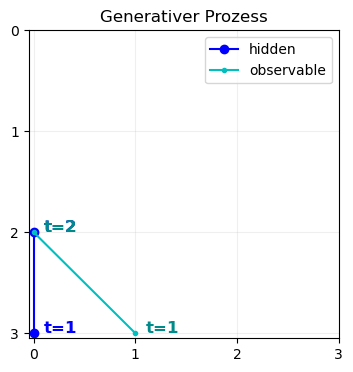

Exact Inference (t = 2):
[[0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.667 0.333 0.    0.   ]
 [0.    0.    0.    0.   ]]

Mean-Field Approximation (t = 2):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 0.]]

Bethe Approximation (t = 2):
[[0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.667 0.333 0.    0.   ]
 [0.    0.    0.    0.   ]]


In [17]:
t = 2

observables = np.zeros((t, 2), dtype=int)
hidden = np.zeros((t, 2), dtype=int)
hidden[0] = sample(D)
for i in range(t):
    observables[i, :] = sample(A[hidden[i, 0], hidden[i, 1]])
    if i < t - 1:
        hidden[i + 1, :] = sample(B[hidden[i, 0], hidden[i, 1]])

plt.figure(figsize=(4, 4))
plt.title("Generativer Prozess")
x_hidden = hidden[:, 1]
y_hidden = hidden[:, 0]
plt.plot(x_hidden, y_hidden, marker='o', linestyle='-', color='b', label="hidden")
x_observables = observables[:, 1]
y_observables = observables[:, 0]
plt.plot(x_observables, y_observables, marker='.', linestyle='-', color='c', label="observable")
plt.text(x_hidden[0] + 0.1, y_hidden[0], 't=1', color='blue', fontsize=12, fontweight='bold')
plt.text(x_hidden[1] + 0.1, y_hidden[1], 't=2', color='blue', fontsize=12, fontweight='bold')
plt.text(x_observables[0] + 0.1, y_observables[0], 't=1', color='darkcyan', fontsize=12, fontweight='bold')
plt.text(x_observables[1] + 0.1, y_observables[1], 't=2', color='darkcyan', fontsize=12, fontweight='bold')

# Achsen und Legende
plt.xticks([0, 1, 2, 3])
plt.yticks([0, 1, 2, 3])
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

np.set_printoptions(precision=3, suppress=True)
print('Exact Inference (t = 2):')
print(infer_exact(observables, A, D, B, t=2))
print()
print('Mean-Field Approximation (t = 2):')
print(infer_meanfield(observables, A, D, B, t=2))
print()
print('Bethe Approximation (t = 2):')
print(infer_bethe(observables, A, D, B, t=2))